In [5]:
import umap
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.manifold import trustworthiness

from pathlib import Path
import os 

In [6]:
BASE_DIR = Path("umap_components.ipynb").resolve().parent.parent.parent
csv_name = os.path.join(BASE_DIR, "data", "2026-02-MD_processed.csv")

In [7]:
X = pd.read_csv(
    csv_name,
    index_col = 0
)

X.describe()

,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
count,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,...,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02,8.030000e+02
mean,-1.769720e-17,-4.424301e-18,-1.283047e-16,2.433366e-17,5.751591e-17,4.424301e-18,-1.769720e-17,8.848602e-18,2.654581e-17,-8.848602e-18,...,-1.603809e-17,1.548505e-17,8.986861e-18,9.954677e-18,1.576157e-17,5.475072e-17,-6.359933e-18,5.806895e-18,-1.714417e-17,-1.283047e-16
std,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,...,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00,1.000623e+00
min,-6.761413e+00,-7.279620e+00,-5.058460e+00,-4.728367e+00,-7.662762e+00,-5.560631e+00,-6.422312e+00,-6.232835e+00,-5.573585e+00,-7.414389e+00,...,-6.103380e+00,-5.974399e+00,-7.548948e+00,-6.432713e+00,-5.699788e+00,-5.030395e+00,-6.002442e+00,-7.235000e+00,-7.896912e+00,-1.432422e+00
25%,-3.371927e-01,-4.410713e-01,-4.814260e-01,-5.011383e-01,-4.371995e-01,-4.743347e-01,-5.291382e-01,-4.974936e-01,-5.304167e-01,-4.234299e-01,...,-4.300059e-01,-5.286050e-01,-5.473831e-01,-4.041837e-01,-5.103916e-01,-4.193538e-01,-3.308075e-01,-3.451407e-01,-5.279421e-01,-7.009149e-01
50%,2.787385e-02,4.047215e-02,-3.227340e-02,-6.088243e-03,2.744100e-02,2.835483e-02,7.956988e-03,-5.966010e-03,-1.149576e-03,1.800293e-02,...,2.750645e-03,-3.968677e-02,-2.888757e-03,-1.146269e-02,-1.888919e-03,-1.044273e-02,1.155477e-02,4.998966e-02,3.807775e-02,-2.072798e-01
75%,4.131000e-01,4.588318e-01,5.117966e-01,5.135632e-01,4.671353e-01,5.121791e-01,5.485987e-01,5.482236e-01,5.155903e-01,4.412737e-01,...,4.735303e-01,4.975496e-01,4.948990e-01,3.824777e-01,4.488970e-01,4.269765e-01,3.212293e-01,4.359867e-01,5.337208e-01,4.281468e-01
max,7.418563e+00,7.263242e+00,9.026554e+00,6.738309e+00,7.463401e+00,7.247277e+00,8.263393e+00,9.144872e+00,8.715777e+00,7.346835e+00,...,4.520144e+00,1.010574e+01,4.937993e+00,6.263905e+00,5.267733e+00,5.067201e+00,6.040932e+00,8.036008e+00,4.639053e+00,6.375515e+00


In [8]:
def fit_umap(X: pd.DataFrame,
             n_components: int = 4,
             n_neighbors: int = 15,
             min_dist: float = 0.0,
             random_state: int = 42):
    
    mapper = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=random_state
    )

    X_reduced = mapper.fit_transform(X.values)

    X_reduced_df = pd.DataFrame(
        X_reduced, 
        index=X.index, 
        columns=[f"UMAP_{i+1}" for i in range(n_components)]
    )

    return X_reduced_df, mapper


In [9]:
components = [c for c in range(2,10)]
n_neighbors_trust = [n for n in range(3, 10)]


results = {
    "components": [],
    "n_neighbors": [],
    "trustworthiness":[]
}

for comp in components:
    for r in n_neighbors_trust:
        X_embedded, _ = fit_umap(
            X,
            n_components = comp,
            n_neighbors = r,
        )

        trust = trustworthiness(X=X, X_embedded=X_embedded, n_neighbors=r)

        results["components"].append(comp)
        results["n_neighbors"].append(r)
        results["trustworthiness"].append(trust)


res = pd.DataFrame(results).sort_values(by = "trustworthiness", ascending=False)

/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeW

In [10]:
res.sort_values(by= ["n_neighbors", "trustworthiness"])

,components,n_neighbors,trustworthiness
0,2,3,0.847216
7,3,3,0.849451
42,8,3,0.851997
14,4,3,0.855764
28,6,3,0.855829
21,5,3,0.858941
49,9,3,0.859310
35,7,3,0.864641
1,2,4,0.827299
15,4,4,0.840328


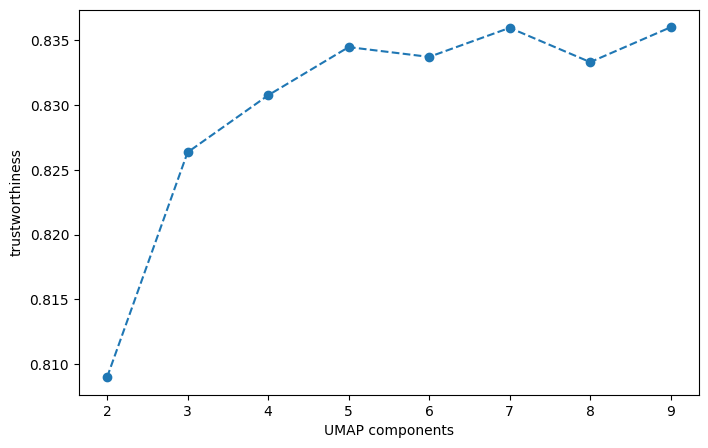

In [11]:
fig, ax = plt.subplots(figsize = (8,5))


ax.plot(res.groupby("components")["trustworthiness"].mean(), marker = 'o', linestyle = '--')
plt.ylabel("trustworthiness")
plt.xlabel("UMAP components")
plt.show()

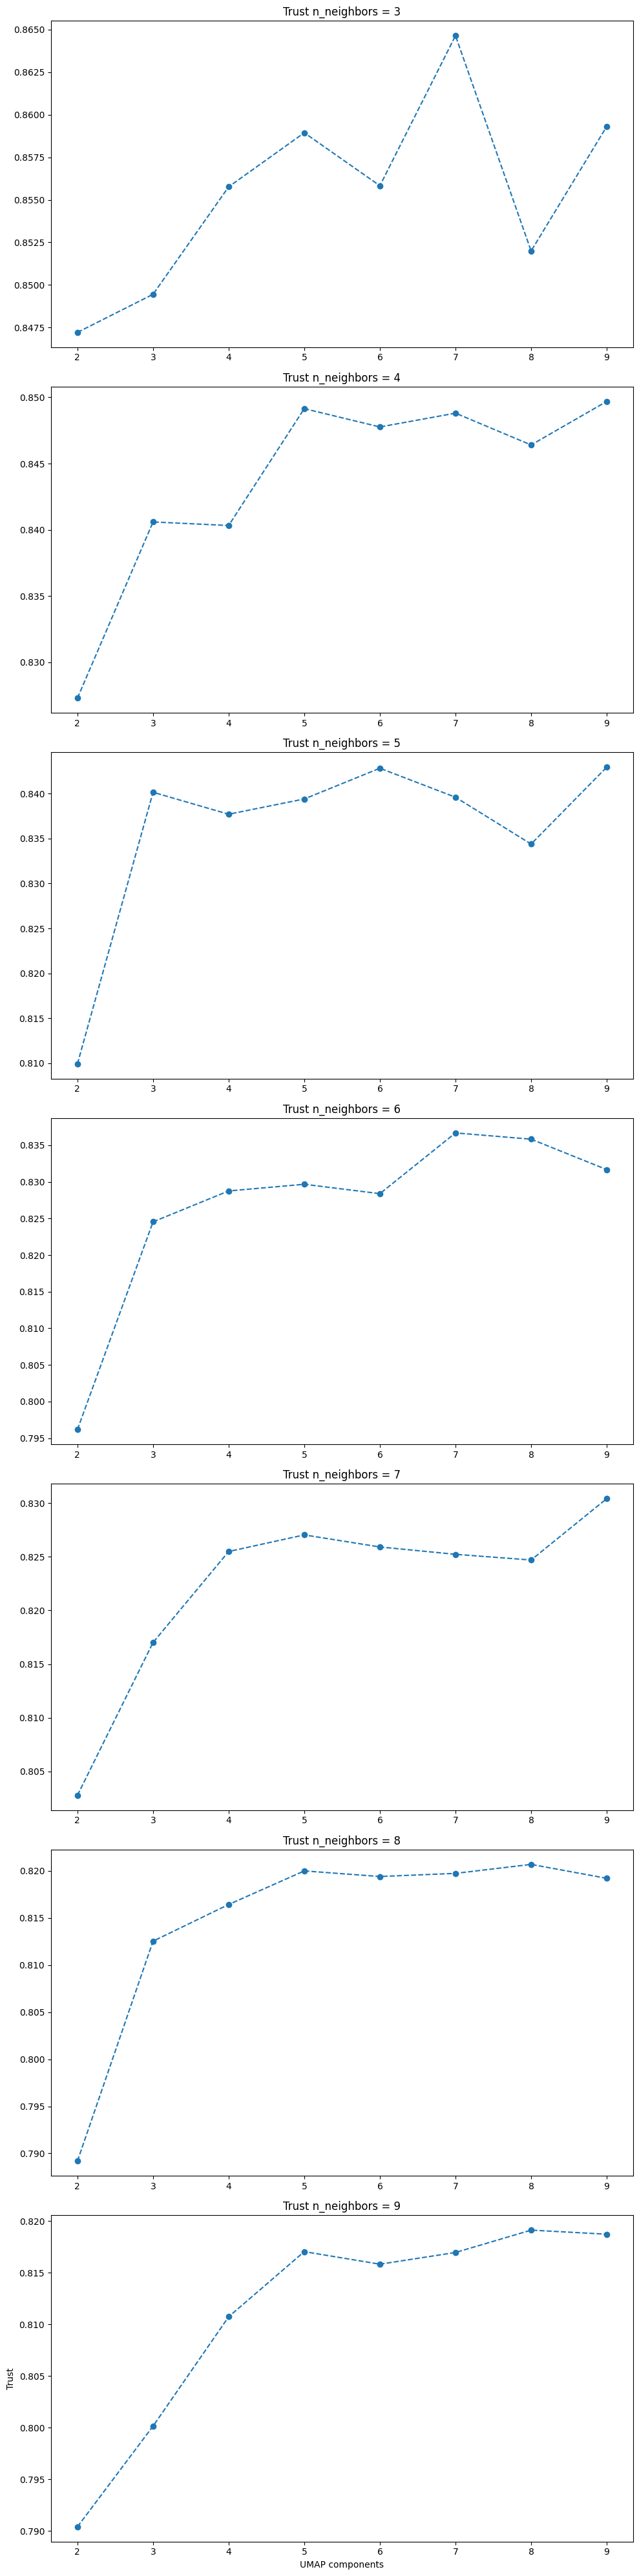

In [12]:
n_plots_neighbors = len(n_neighbors_trust)

fig, ax = plt.subplots(nrows = n_plots_neighbors, ncols = 1, figsize = (10,40))
ax = ax.flatten()

data = pd.Series(res.sort_values("components").groupby("n_neighbors")["trustworthiness"])

for i, n in zip(range(n_plots_neighbors), n_neighbors_trust):
    neigh, d = data.loc[i]
    ax[i].plot(components,d, marker = "o", linestyle = '--')
    ax[i].set_title(f"Trust n_neighbors = {neigh}")
    plt.xlabel("UMAP components")
    plt.ylabel("Trust")

plt.tight_layout()

---
## 3 · Contamination Rate Tuning

**Goal:** find the contamination value that makes regime 0 best match historical crisis periods.

**Proxy for "true" crisis:** the `VIXCLSx` column (already z-scored). We define crisis = top P% of VIX observations, then score each contamination level by F1 / precision / recall against that label.

We sweep:
- `contamination` ∈ [0.03, 0.25]  
- VIX threshold at top **10 %, 15 %, 20 %** — the middle value is the working assumption for known macro crises (GFC 2008-09, COVID 2020, dot-com 2000-02 etc. represent roughly 12-15 % of months since 1959).

In [ ]:
import sys
import numpy as np
sys.path.insert(0, str(BASE_DIR / "src"))

from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, precision_score, recall_score

vix_vals = X["VIXCLSx"].values
contamination_grid = np.linspace(0.03, 0.25, 25)
vix_crisis_pcts   = [0.10, 0.15, 0.20]

rows = []
for vix_pct in vix_crisis_pcts:
    vix_thr   = np.quantile(vix_vals, 1 - vix_pct)
    vix_label = (vix_vals >= vix_thr).astype(int)
    for cont in contamination_grid:
        iso   = IsolationForest(n_estimators=200, contamination=cont, bootstrap=True, random_state=42)
        pred  = iso.fit_predict(X.values)
        iso_label = (pred == -1).astype(int)
        rows.append({
            "contamination": cont,
            "vix_pct":       vix_pct,
            "f1":       f1_score(vix_label, iso_label, zero_division=0),
            "precision": precision_score(vix_label, iso_label, zero_division=0),
            "recall":   recall_score(vix_label, iso_label, zero_division=0),
            "n_regime0": iso_label.sum(),
        })

df_cont = pd.DataFrame(rows)

# best contamination per VIX threshold
print("Best contamination by F1 for each VIX threshold:")
print(df_cont.loc[df_cont.groupby("vix_pct")["f1"].idxmax()][
    ["vix_pct", "contamination", "f1", "precision", "recall", "n_regime0"]
].to_string(index=False))

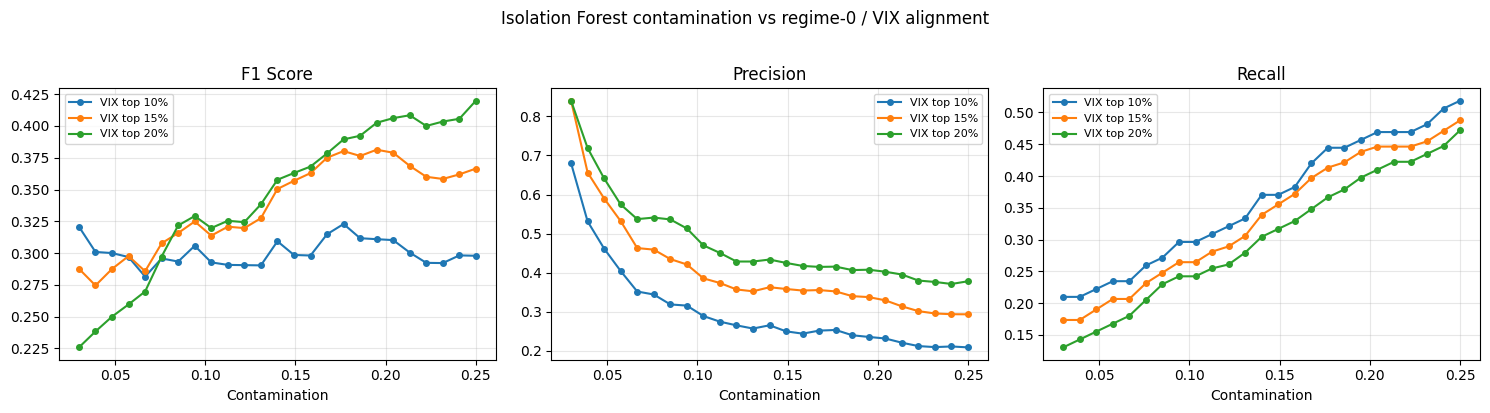

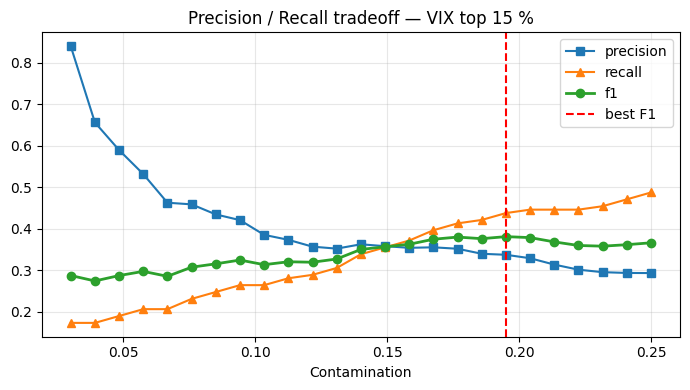

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [("f1", "F1 Score"), ("precision", "Precision"), ("recall", "Recall")]

for ax, (metric, title) in zip(axes, metrics):
    for vix_pct in vix_crisis_pcts:
        sub = df_cont[df_cont["vix_pct"] == vix_pct].sort_values("contamination")
        ax.plot(sub["contamination"], sub[metric], marker="o", markersize=4,
                label=f"VIX top {int(vix_pct*100)}%")
    ax.set_title(title)
    ax.set_xlabel("Contamination")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Isolation Forest contamination vs regime-0 / VIX alignment", y=1.02)
plt.tight_layout()
plt.show()

# helper: show the precision-recall tradeoff at each contamination for vix_pct=0.15
sub15 = df_cont[df_cont["vix_pct"] == 0.15].sort_values("contamination")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sub15["contamination"], sub15["precision"], label="precision", marker="s")
ax.plot(sub15["contamination"], sub15["recall"],    label="recall",    marker="^")
ax.plot(sub15["contamination"], sub15["f1"],        label="f1",        marker="o", linewidth=2)
ax.axvline(sub15.loc[sub15["f1"].idxmax(), "contamination"], color="r",
           linestyle="--", label="best F1")
ax.set_xlabel("Contamination")
ax.set_title("Precision / Recall tradeoff — VIX top 15 %")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4 · PCA Pre-processing: Raw vs PCA-reduced

High-dimensional data (104 features) contains redundancy and noise that can degrade UMAP topology preservation. We test:
- **Raw** 104-dim standardised macro features
- **PCA → UMAP**: compress first to 95 % explained variance, then embed

Two evaluation axes:
1. UMAP `trustworthiness` — does the low-dim neighbourhood structure reflect the original?
2. Regime-0 vs VIX alignment — does the crisis cluster improve?

PCA components for 95% variance: 58


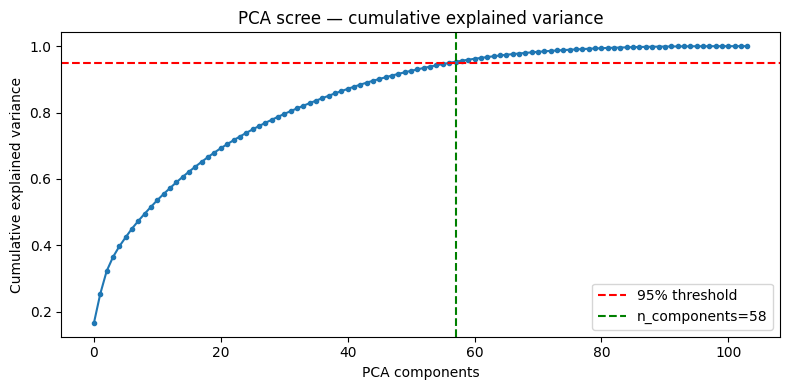

/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:351: Run

In [18]:
from sklearn.decomposition import PCA
from sklearn.manifold import trustworthiness

# Scree: how many PCA components for 95% variance?
pca_full = PCA(random_state=42)
pca_full.fit(X.values)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_pca = int(np.argmax(cum_var >= 0.95)) + 1
print(f"PCA components for 95% variance: {n_pca}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cum_var, marker="o", markersize=3)
ax.axhline(0.95, color="r", linestyle="--", label="95% threshold")
ax.axvline(n_pca - 1, color="g", linestyle="--", label=f"n_components={n_pca}")
ax.set_xlabel("PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.legend()
plt.title("PCA scree — cumulative explained variance")
plt.tight_layout()
plt.show()

pca = PCA(n_components=n_pca, random_state=42)
X_pca = pd.DataFrame(
    pca.fit_transform(X.values), index=X.index,
    columns=[f"PC_{i+1}" for i in range(n_pca)],
)

/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeW

 n_neighbors  trust_raw  trust_pca  trust_pca_vs_raw
           3   0.855764   0.864365          0.858623
           5   0.837710   0.843552          0.838466
           7   0.825497   0.831612          0.827002
          10   0.807431   0.816917          0.811943
          15   0.794467   0.803494          0.798622


/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users

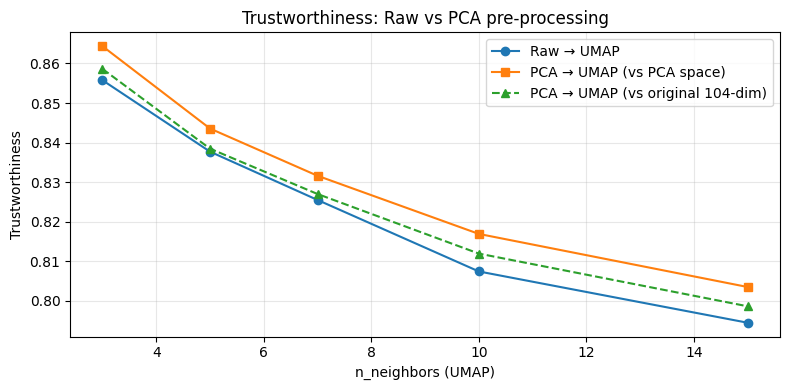

In [19]:
# Trustworthiness: raw vs PCA → UMAP (sweep n_neighbors)
k_vals = [3, 5, 7, 10, 15]
umap_dims = 4

trust_rows = []
for k in k_vals:
    umap_p = dict(n_components=umap_dims, n_neighbors=k, min_dist=0.0, random_state=42)

    raw_emb, _ = fit_umap(X, **umap_p)
    pca_emb, _ = fit_umap(X_pca, **umap_p)

    trust_rows.append({
        "n_neighbors":  k,
        "trust_raw":    trustworthiness(X.values,     raw_emb.values, n_neighbors=k),
        "trust_pca":    trustworthiness(X_pca.values, pca_emb.values, n_neighbors=k),
        # trustworthiness w.r.t original 104-dim space for PCA path
        "trust_pca_vs_raw": trustworthiness(X.values, pca_emb.values, n_neighbors=k),
    })

df_trust = pd.DataFrame(trust_rows)
print(df_trust.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_trust["n_neighbors"], df_trust["trust_raw"],         marker="o", label="Raw → UMAP")
ax.plot(df_trust["n_neighbors"], df_trust["trust_pca"],         marker="s", label="PCA → UMAP (vs PCA space)")
ax.plot(df_trust["n_neighbors"], df_trust["trust_pca_vs_raw"],  marker="^", linestyle="--",
        label="PCA → UMAP (vs original 104-dim)")
ax.set_xlabel("n_neighbors (UMAP)")
ax.set_ylabel("Trustworthiness")
ax.legend()
ax.grid(True, alpha=0.3)
plt.title("Trustworthiness: Raw vs PCA pre-processing")
plt.tight_layout()
plt.show()

In [20]:
from models.Isolation import Isolation_UMAP_HMM

# Reference: VIX top 15% as crisis label
VIX_PCT = 0.15
vix_thr    = np.quantile(vix_vals, 1 - VIX_PCT)
vix_crisis = (vix_vals >= vix_thr).astype(int)

BEST_CONT = df_cont.loc[
    df_cont[df_cont["vix_pct"] == VIX_PCT]["f1"].idxmax(), "contamination"
]
print(f"Using best contamination from section 3: {BEST_CONT:.4f}")

BASE_PARAMS = dict(
    r=4, n_estimators=200, contamination=BEST_CONT,
    umap_components=4, umap_n_neighbors=7, umap_min_dist=0.0,
    umap_metric="cosine", umap_epochs=500,
    hmm_covariance_type="diag", hmm_n_iter=500, hmm_tol=1e-6,
    hmm_min_covar=1e-2, iso_score_scale=5.0, prob_mode="soft", random_state=42,
)

results_pca = {}
for label, data_in in [("Raw (104-dim)", X), (f"PCA ({n_pca}-dim)", X_pca)]:
    regimes, probs, pred_iso, umap_df, hmm_states, _, _, anomaly_mask = \
        Isolation_UMAP_HMM(data_in, **BASE_PARAMS)
    iso_label = anomaly_mask.astype(int)
    results_pca[label] = {
        "f1":         f1_score(vix_crisis, iso_label, zero_division=0),
        "precision":  precision_score(vix_crisis, iso_label, zero_division=0),
        "recall":     recall_score(vix_crisis, iso_label, zero_division=0),
        "n_regime0":  anomaly_mask.sum(),
    }
    print(f"\n{label}:")
    for k, v in results_pca[label].items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Using best contamination from section 3: 0.1950


/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: divide by zero encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: over


Raw (104-dim):
  f1: 0.3813
  precision: 0.3376
  recall: 0.4380
  n_regime0: 157

PCA (58-dim):
  f1: 0.3165
  precision: 0.2803
  recall: 0.3636
  n_regime0: 157


/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: divide by zero encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: overflow encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: invalid value encoun

---
## 5 · Full Pipeline Hyperparameter Grid

We run a 2D sweep of the most impactful UMAP parameters (other params fixed at best values from above):

| Axis | Values | Why it matters |
|------|--------|----------------|
| `umap_n_neighbors` | 5, 7, 10, 15 | Controls local vs global structure; small = local clusters, large = global manifold |
| `umap_components` | 3, 4, 5 | HMM input dimensionality — more dims = richer state space but harder to fit |

Score: F1(regime-0 vs VIX top 15 %). Run on the **better** of raw/PCA from section 4.

In [21]:
import itertools

# pick the input data that scored higher F1 in section 4
best_input_label = max(results_pca, key=lambda k: results_pca[k]["f1"])
best_input_data  = X if "Raw" in best_input_label else X_pca
print(f"Best input: {best_input_label}")

n_neighbors_grid  = [5, 7, 10, 15]
n_components_grid = [3, 4, 5]
covariance_types  = ["diag", "full"]

grid_rows = []
for n_neigh, n_comp, cov_type in itertools.product(
        n_neighbors_grid, n_components_grid, covariance_types):
    params = {**BASE_PARAMS,
              "umap_n_neighbors": n_neigh,
              "umap_components":  n_comp,
              "hmm_covariance_type": cov_type}
    try:
        _, _, _, _, _, _, hmm_model, anomaly_mask = Isolation_UMAP_HMM(best_input_data, **params)
        iso_label = anomaly_mask.astype(int)
        f1   = f1_score(vix_crisis, iso_label, zero_division=0)
        prec = precision_score(vix_crisis, iso_label, zero_division=0)
        rec  = recall_score(vix_crisis, iso_label, zero_division=0)
        converged = getattr(getattr(hmm_model, "monitor_", None), "converged", None)
    except Exception as e:
        f1 = prec = rec = float("nan")
        converged = False

    grid_rows.append({
        "n_neighbors":   n_neigh,
        "n_components":  n_comp,
        "cov_type":      cov_type,
        "f1":            f1,
        "precision":     prec,
        "recall":        rec,
        "hmm_converged": converged,
    })
    print(f"n_neigh={n_neigh:2d} n_comp={n_comp} cov={cov_type:4s}  f1={f1:.4f}  converged={converged}")

df_grid = pd.DataFrame(grid_rows)
print("\nTop 10 configs by F1:")
print(df_grid.sort_values("f1", ascending=False).head(10).to_string(index=False))

/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Best input: Raw (104-dim)


/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: divide by zero encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: overflow encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: invalid value encoun

n_neigh= 5 n_comp=3 cov=diag  f1=0.3813  converged=True


/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: divide by zero encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: overflow encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: invalid value encoun

...

n_neigh=15 n_comp=4 cov=full  f1=0.3813  converged=True


/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: divide by zero encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: over

n_neigh=15 n_comp=5 cov=diag  f1=0.3813  converged=True


/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: divide by zero encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: overflow encountered in matmul
  stats['obs'] += posteriors.T @ X
/Users/yanisfallet/.pyenv/versions/3.13.0/lib/python3.13/site-packages/hmmlearn/_emissions.py:153: RuntimeWarning: invalid value encoun

n_neigh=15 n_comp=5 cov=full  f1=0.3813  converged=True

Top 10 configs by F1:
 n_neighbors  n_components cov_type       f1  precision   recall  hmm_converged
           5             3     diag 0.381295    0.33758 0.438017           True
           5             3     full 0.381295    0.33758 0.438017           True
          15             5     diag 0.381295    0.33758 0.438017           True
          15             4     full 0.381295    0.33758 0.438017           True
          15             4     diag 0.381295    0.33758 0.438017           True
          15             3     full 0.381295    0.33758 0.438017           True
          15             3     diag 0.381295    0.33758 0.438017           True
          10             5     full 0.381295    0.33758 0.438017           True
          10             5     diag 0.381295    0.33758 0.438017           True
          10             4     full 0.381295    0.33758 0.438017           True


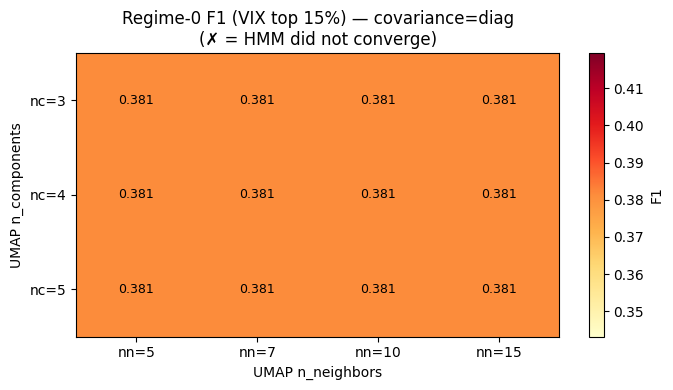

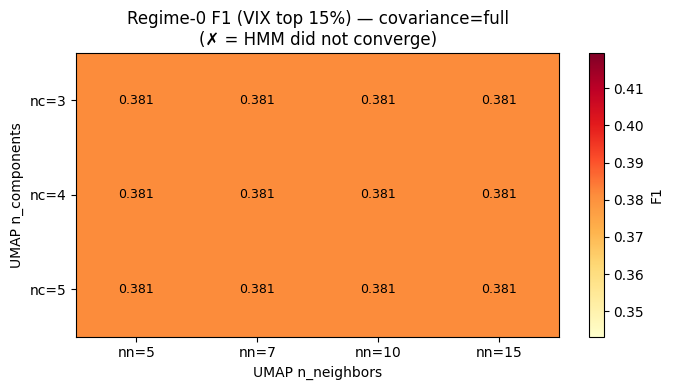

In [22]:
import matplotlib.colors as mcolors

for cov_type in covariance_types:
    sub = df_grid[df_grid["cov_type"] == cov_type]
    pivot = sub.pivot(index="n_components", columns="n_neighbors", values="f1")

    fig, ax = plt.subplots(figsize=(7, 4))
    im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd",
                   vmin=df_grid["f1"].min(), vmax=df_grid["f1"].max())
    ax.set_xticks(range(len(n_neighbors_grid)))
    ax.set_xticklabels([f"nn={v}" for v in n_neighbors_grid])
    ax.set_yticks(range(len(n_components_grid)))
    ax.set_yticklabels([f"nc={v}" for v in n_components_grid])

    for i in range(len(n_components_grid)):
        for j in range(len(n_neighbors_grid)):
            val = pivot.values[i, j]
            conv = sub[
                (sub["n_components"] == n_components_grid[i]) &
                (sub["n_neighbors"]  == n_neighbors_grid[j])
            ]["hmm_converged"].values[0]
            marker = "" if conv else " ✗"
            ax.text(j, i, f"{val:.3f}{marker}", ha="center", va="center", fontsize=9)

    plt.colorbar(im, ax=ax, label="F1")
    ax.set_title(f"Regime-0 F1 (VIX top 15%) — covariance={cov_type}\n(✗ = HMM did not converge)")
    ax.set_xlabel("UMAP n_neighbors")
    ax.set_ylabel("UMAP n_components")
    plt.tight_layout()
    plt.show()